# Road Accident Severity Prediction Using Machine Learning

## Project Overview

This project analyzes road traffic accident data and builds machine-learning models to predict accident severity.

The analysis examines relationships between accident severity and weather, lighting, road surface, time of day, day of week, and collision type. Logistic Regression, Decision Tree, Random Forest, and XGBoost models are compared using multiple classification metrics. Additional evaluation includes stratified cross-validation, multiclass ROC-AUC, feature importance, and a class-weighting experiment for XGBoost.

## Modeling Approach

Because accident-severity classes are imbalanced, the project emphasizes metrics such as balanced accuracy, macro precision, macro recall, and macro F1 in addition to overall accuracy. A weighted XGBoost experiment is also used to evaluate whether additional emphasis on minority severity classes improves performance.


## 1. Import Libraries

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import balanced_accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier

## 2. Set Project Paths and Configuration

In [2]:
sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

CURRENT_DIR = Path.cwd()

# Support running from either the project root or the notebooks folder.
if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

DATA_DIR = PROJECT_DIR / "data"
FIGURES_DIR = PROJECT_DIR / "figures"
RESULTS_DIR = PROJECT_DIR / "results"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DATA_FILE = DATA_DIR / "RTA Dataset.csv"

print("Project folders ready:")
print(" - data/")
print(" - figures/")
print(" - results/")


Project folders ready:
 - data/
 - figures/
 - results/


## 3. Load the Dataset

In [3]:
df = pd.read_csv(DATA_FILE)

print("Dataset Shape:", df.shape)

display(df.head())

Dataset Shape: (12316, 32)


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,No defect,Residential areas,NaN,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside-parked vehicles,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,No defect,Office areas,Undivided Two way,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,No defect,Recreational areas,other,NaN,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside objects,2,2,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,No defect,Office areas,other,Tangent road with mild grade and flat terrain,Y Shape,Earth roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,No defect,Industrial areas,other,Tangent road with flat terrain,Y Shape,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


## 4. Inspect the Dataset

In [4]:
# Display data types and non-null counts.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians             11931 non-null  object
 13  Road_allignment              12

## 5. Clean the Data

In [5]:
# Review missing values before preprocessing.
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().mean() * 100).round(2)
})

missing_summary = (
    missing_summary[
        missing_summary["Missing Values"] > 0
    ]
    .sort_values(
        by="Missing Values",
        ascending=False
    )
)

display(missing_summary)

# Check and remove exact duplicate records.
duplicate_count = df.duplicated().sum()

print("Duplicate Rows:", duplicate_count)

df.drop_duplicates(inplace=True)

,Missing Values,Percentage
Defect_of_vehicle,4427,35.95
Service_year_of_vehicle,3928,31.89
Work_of_casuality,3198,25.97
Fitness_of_casuality,2635,21.39
Type_of_vehicle,950,7.71
Types_of_Junction,887,7.20
Driving_experience,829,6.73
Educational_level,741,6.02
Vehicle_driver_relation,579,4.70
Owner_of_vehicle,482,3.91


Duplicate Rows: 0


## 6. Engineer Time-Based Features

In [6]:
# Convert accident time and create more useful time-based features.
df["Time"] = pd.to_datetime(
    df["Time"],
    format="%H:%M:%S",
    errors="coerce"
)

df["Hour"] = df["Time"].dt.hour


def classify_time(hour):

    if pd.isna(hour):
        return "Unknown"

    elif 5 <= hour < 12:
        return "Morning"

    elif 12 <= hour < 17:
        return "Afternoon"

    elif 17 <= hour < 21:
        return "Evening"

    else:
        return "Night"


df["Time_of_day"] = df["Hour"].apply(classify_time)

## 7. Analyze Accident Severity Distribution

,Count,Percentage
Accident_severity,,
Slight Injury,10415,84.56
Serious Injury,1743,14.15
Fatal injury,158,1.28


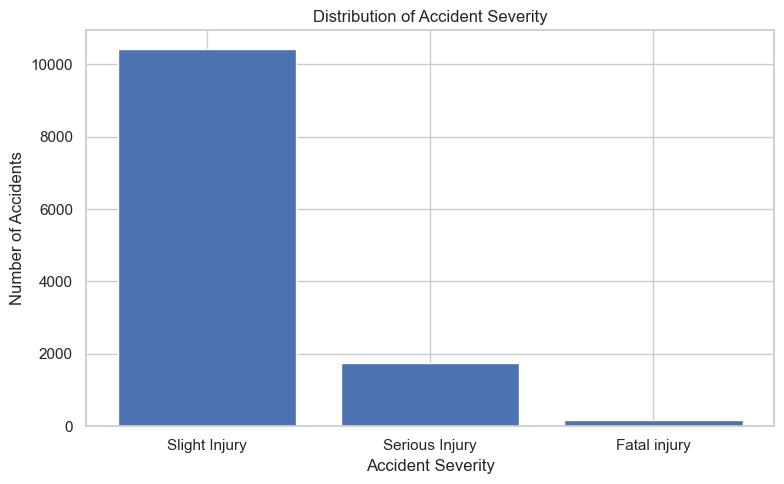

Saved: figures/accident_severity_distribution.png


In [7]:
# Examine the target class distribution.
severity_summary = pd.DataFrame({
    "Count": df["Accident_severity"].value_counts(),
    "Percentage": (
        df["Accident_severity"]
        .value_counts(normalize=True) * 100
    ).round(2)
})

display(severity_summary)

severity_counts = df["Accident_severity"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    severity_counts.index,
    severity_counts.values
)

plt.title("Distribution of Accident Severity")
plt.xlabel("Accident Severity")
plt.ylabel("Number of Accidents")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "accident_severity_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: figures/accident_severity_distribution.png")

## 8. Analyze Weather Conditions

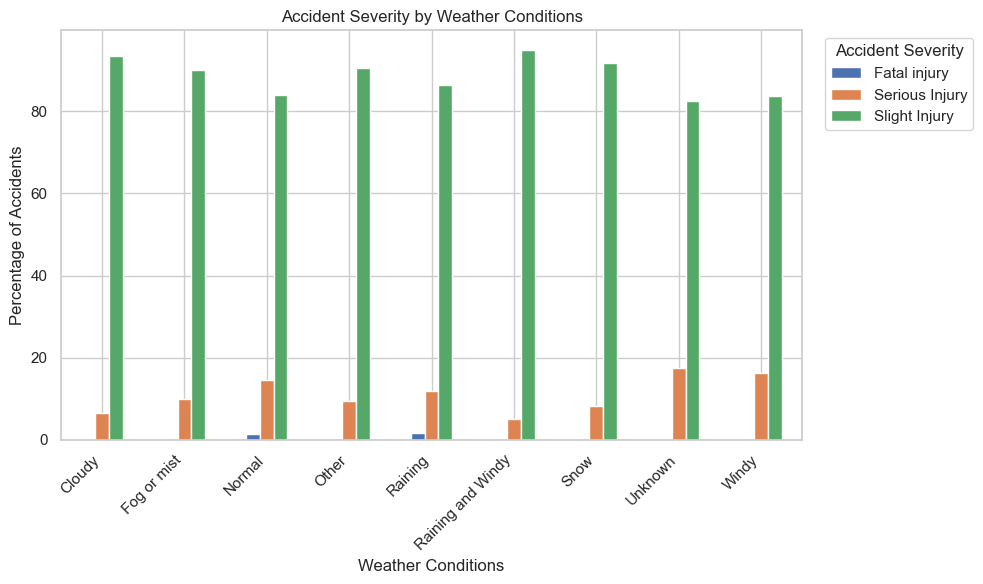

Saved: figures/severity_by_weather.png


In [8]:
# Compare accident severity percentages across weather conditions.
weather_table = pd.crosstab(
    df["Weather_conditions"],
    df["Accident_severity"],
    normalize="index"
) * 100

weather_table.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Accident Severity by Weather Conditions")
plt.xlabel("Weather Conditions")
plt.ylabel("Percentage of Accidents")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend(
    title="Accident Severity",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "severity_by_weather.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: figures/severity_by_weather.png")

## 9. Analyze Light Conditions

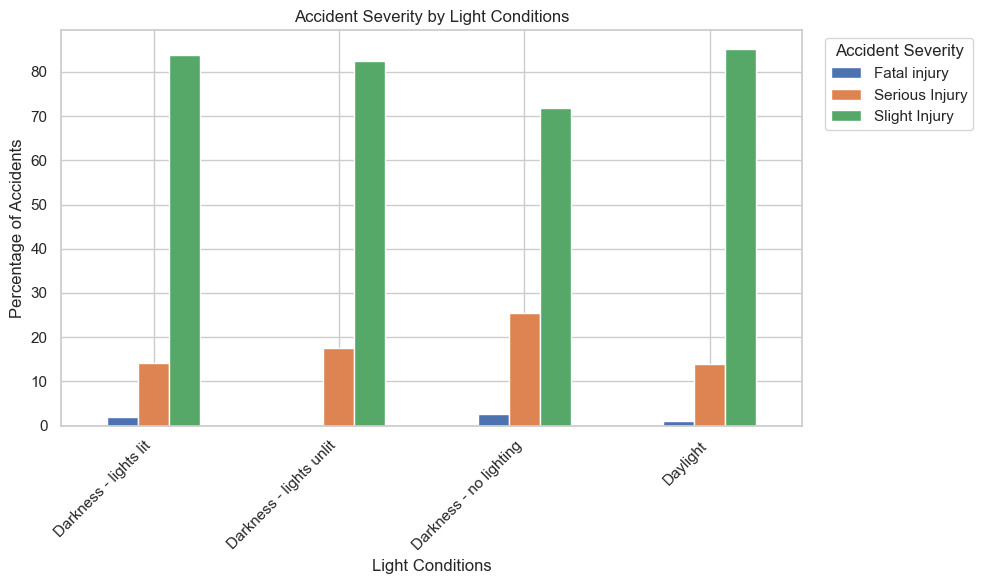

Saved: figures/severity_by_light_conditions.png


In [9]:
light_table = pd.crosstab(
    df["Light_conditions"],
    df["Accident_severity"],
    normalize="index"
) * 100

light_table.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Accident Severity by Light Conditions")
plt.xlabel("Light Conditions")
plt.ylabel("Percentage of Accidents")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend(
    title="Accident Severity",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "severity_by_light_conditions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: figures/severity_by_light_conditions.png")

## 10. Analyze Road Surface Conditions

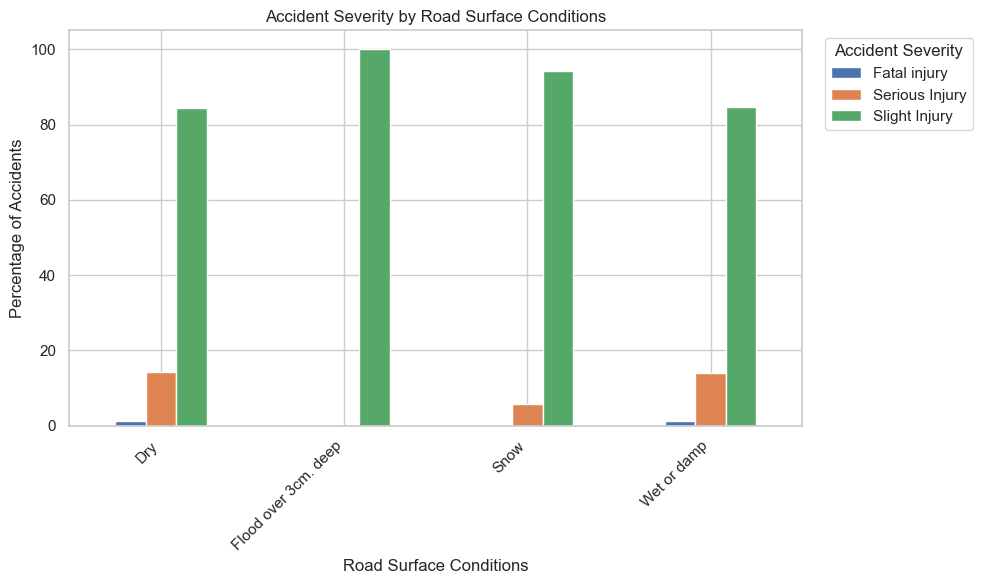

Saved: figures/severity_by_road_surface.png


In [10]:
surface_table = pd.crosstab(
    df["Road_surface_conditions"],
    df["Accident_severity"],
    normalize="index"
) * 100

surface_table.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Accident Severity by Road Surface Conditions")
plt.xlabel("Road Surface Conditions")
plt.ylabel("Percentage of Accidents")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend(
    title="Accident Severity",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "severity_by_road_surface.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: figures/severity_by_road_surface.png")

## 11. Analyze Time of Day

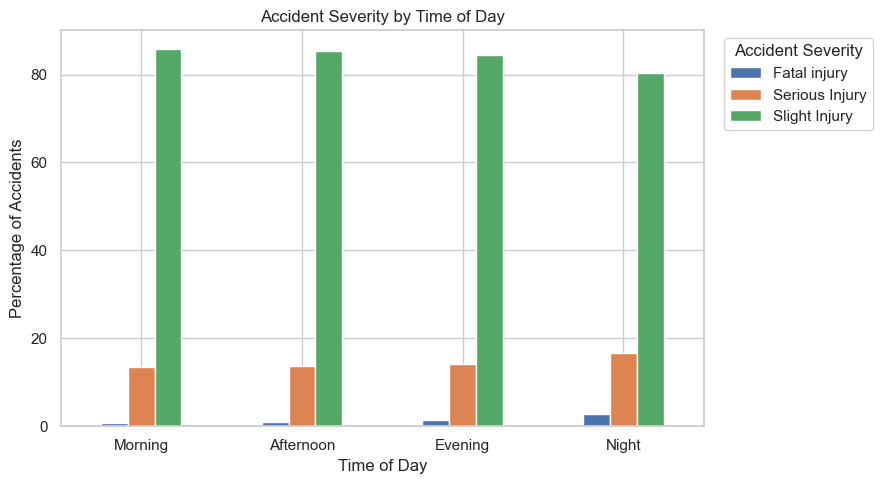

Saved: figures/severity_by_time_of_day.png


In [11]:
time_table = pd.crosstab(
    df["Time_of_day"],
    df["Accident_severity"],
    normalize="index"
) * 100

time_order = [
    "Morning",
    "Afternoon",
    "Evening",
    "Night"
]

time_table = time_table.reindex(
    [
        value
        for value in time_order
        if value in time_table.index
    ]
)

time_table.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Accident Severity by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Percentage of Accidents")

plt.xticks(rotation=0)

plt.legend(
    title="Accident Severity",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "severity_by_time_of_day.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: figures/severity_by_time_of_day.png")

## 12. Analyze Day of Week

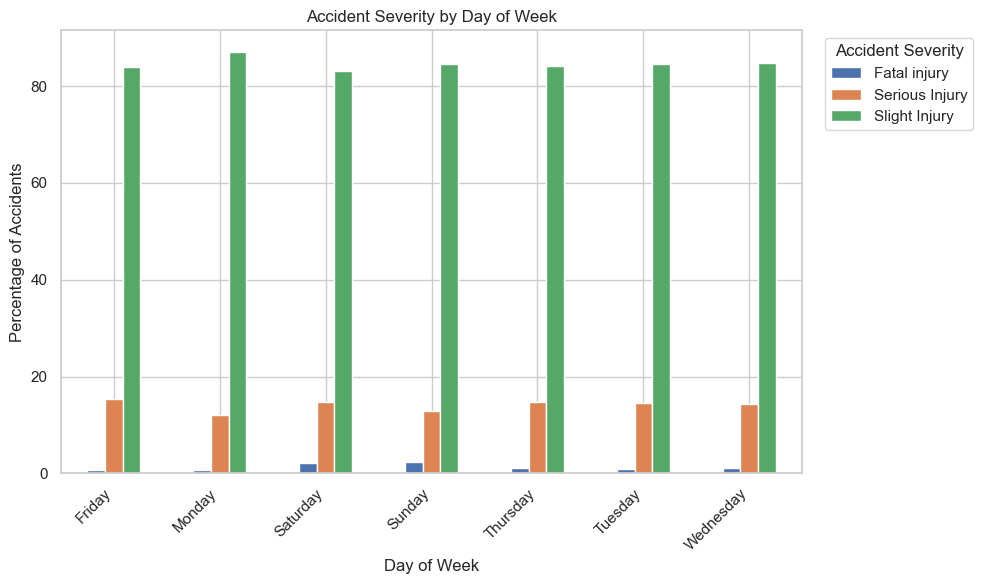

Saved: figures/severity_by_day_of_week.png


In [12]:
day_table = pd.crosstab(
    df["Day_of_week"],
    df["Accident_severity"],
    normalize="index"
) * 100

day_table.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Accident Severity by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Percentage of Accidents")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend(
    title="Accident Severity",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "severity_by_day_of_week.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: figures/severity_by_day_of_week.png")

## 13. Analyze Collision Type

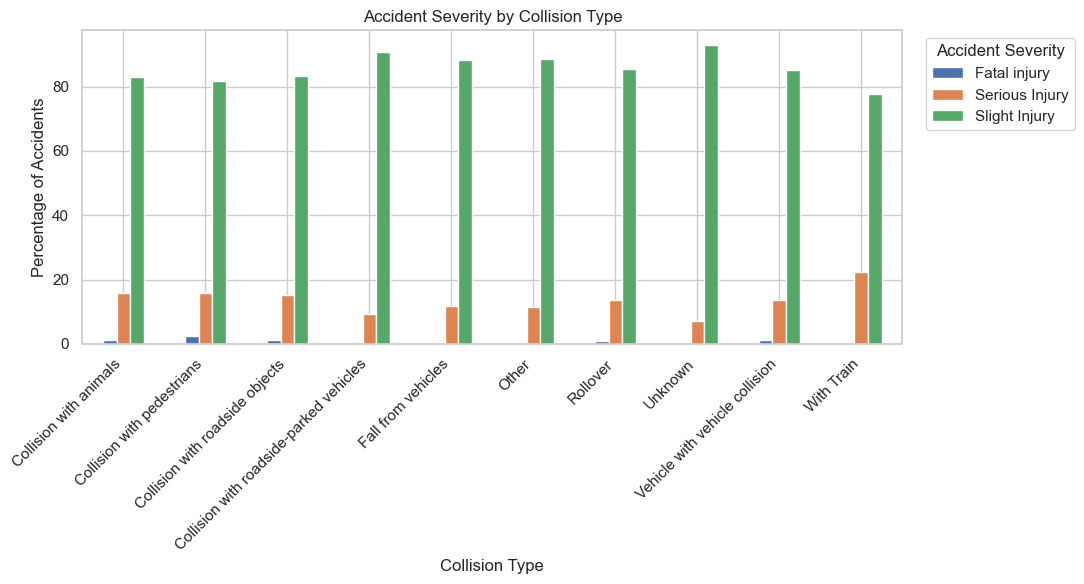

Saved: figures/severity_by_collision_type.png


In [13]:
collision_table = pd.crosstab(
    df["Type_of_collision"],
    df["Accident_severity"],
    normalize="index"
) * 100

collision_table.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Accident Severity by Collision Type")
plt.xlabel("Collision Type")
plt.ylabel("Percentage of Accidents")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend(
    title="Accident Severity",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "severity_by_collision_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: figures/severity_by_collision_type.png")

## 14. Measure Statistical Association

In [14]:
# Chi-square identifies statistical association.
# Cramer's V measures the strength of that association.

def cramers_v(x, y):

    table = pd.crosstab(x, y)

    chi2, p, dof, expected = chi2_contingency(table)

    n = table.values.sum()

    phi2 = chi2 / n

    r, k = table.shape

    phi2corr = max(
        0,
        phi2 - ((k - 1) * (r - 1)) / (n - 1)
    )

    rcorr = r - (
        ((r - 1) ** 2) / (n - 1)
    )

    kcorr = k - (
        ((k - 1) ** 2) / (n - 1)
    )

    denominator = min(
        kcorr - 1,
        rcorr - 1
    )

    if denominator <= 0:
        return 0

    return np.sqrt(
        phi2corr / denominator
    )


association_features = [
    "Weather_conditions",
    "Light_conditions",
    "Road_surface_conditions",
    "Time_of_day",
    "Day_of_week",
    "Road_allignment",
    "Types_of_Junction",
    "Road_surface_type",
    "Type_of_collision"
]


association_results = []


for feature in association_features:

    temp = df[
        [
            feature,
            "Accident_severity"
        ]
    ].dropna()

    contingency_table = pd.crosstab(
        temp[feature],
        temp["Accident_severity"]
    )

    chi2, p_value, dof, expected = (
        chi2_contingency(
            contingency_table
        )
    )

    cv = cramers_v(
        temp[feature],
        temp["Accident_severity"]
    )

    association_results.append({
        "Feature": feature,
        "Chi-Square": chi2,
        "P-Value": p_value,
        "Cramers V": cv
    })


association_df = (
    pd.DataFrame(
        association_results
    )
    .sort_values(
        by="Cramers V",
        ascending=False
    )
)

display(
    association_df.round(4)
)

,Feature,Chi-Square,P-Value,Cramers V
3,Time_of_day,53.7904,0.0000,0.0441
6,Types_of_Junction,54.0746,0.0000,0.0419
1,Light_conditions,45.0245,0.0000,0.0398
4,Day_of_week,47.2022,0.0000,0.0378
0,Weather_conditions,41.7520,0.0004,0.0323
7,Road_surface_type,11.0081,0.2012,0.0111
8,Type_of_collision,21.0046,0.2792,0.0111
2,Road_surface_conditions,5.7209,0.4552,0.0000
5,Road_allignment,12.9907,0.6734,0.0000


## 15. Prepare Data for Modeling

In [15]:
df_model = df.copy()

df_model = df_model.dropna(
    subset=["Accident_severity"]
)

# Remove the target variable and variables that may introduce
# target leakage or represent post-accident casualty information.
# The original Time variable is removed because Hour and
# Time_of_day were already created during feature engineering.

columns_to_drop = [
    "Accident_severity",
    "Casualty_severity",
    "Casualty_class",
    "Sex_of_casualty",
    "Age_band_of_casualty",
    "Work_of_casuality",
    "Fitness_of_casuality",
    "Time"
]

X = df_model.drop(
    columns=columns_to_drop,
    errors="ignore"
)

y = df_model["Accident_severity"]


# Encode the three accident-severity classes as numeric labels
# so they can be used by the classification models.
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)


print("Target Classes:")

for number, label in enumerate(
    label_encoder.classes_
):
    print(
        number,
        "=",
        label
    )

print("\nNumber of Predictor Variables:", X.shape[1])

Target Classes:
0 = Fatal injury
1 = Serious Injury
2 = Slight Injury

Number of Predictor Variables: 26


## 16. Create Training and Test Sets

In [16]:
# Use stratification to preserve the accident-severity
# distribution in both the training and test datasets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

print("Training Records:", X_train.shape[0])
print("Testing Records:", X_test.shape[0])

Training Records: 9852
Testing Records: 2464


## 17. Build the Preprocessing Pipeline

In [17]:
numeric_features = (
    X_train
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

categorical_features = (
    X_train
    .select_dtypes(exclude=np.number)
    .columns
    .tolist()
)


numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="infrequent_if_exist",
                min_frequency=10
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

## 18. Define Classification Models

In [18]:
models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            max_depth=12,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),

    "XGBoost":
        XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="multi:softprob",
            eval_metric="mlogloss",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
}

## 19. Train and Evaluate Models

In [19]:
# Store model results, fitted pipelines, and predictions.
results = []
fitted_models = {}
predictions = {}


# Train and evaluate each model using the same preprocessing
# pipeline and train/test data for a consistent comparison.
for model_name, model in models.items():

    print("\n" + "=" * 60)
    print("Training:", model_name)
    print("=" * 60)

    # Keep preprocessing and modeling in one pipeline.
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    # Train model
    pipeline.fit(
        X_train,
        y_train
    )

    # Make predictions
    y_pred = pipeline.predict(
        X_test
    )

    # Store fitted model
    fitted_models[model_name] = pipeline

    # Store predictions for later evaluation
    predictions[model_name] = y_pred

    # Macro metrics give equal importance to each severity class.
    # This is useful because the target classes are highly imbalanced.
    results.append({

        "Model":
            model_name,

        "Accuracy":
            accuracy_score(
                y_test,
                y_pred
            ),

        "Balanced Accuracy":
            balanced_accuracy_score(
                y_test,
                y_pred
            ),

        "Macro Precision":
            precision_score(
                y_test,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "Macro Recall":
            recall_score(
                y_test,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "Macro F1":
            f1_score(
                y_test,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "Weighted F1":
            f1_score(
                y_test,
                y_pred,
                average="weighted",
                zero_division=0
            )
    })

    # Display class-level precision, recall, and F1 results.
    print("\nClassification Report:\n")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=label_encoder.classes_,
            zero_division=0
        )
    )


# Convert model results to a DataFrame.
results_df = pd.DataFrame(
    results
)

# Rank models by Macro F1 because it gives equal weight
# to Fatal, Serious, and Slight Injury classes.
results_df = results_df.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(
    drop=True
)


print("\nModel Comparison:\n")

display(
    results_df.round(4)
)


Training: Logistic Regression

Classification Report:

                precision    recall  f1-score   support

  Fatal injury       0.02      0.32      0.04        31
Serious Injury       0.16      0.38      0.23       349
 Slight Injury       0.87      0.51      0.64      2084

      accuracy                           0.49      2464
     macro avg       0.35      0.40      0.31      2464
  weighted avg       0.76      0.49      0.58      2464


Training: Decision Tree

Classification Report:

                precision    recall  f1-score   support

  Fatal injury       0.07      0.42      0.12        31
Serious Injury       0.19      0.56      0.29       349
 Slight Injury       0.89      0.54      0.67      2084

      accuracy                           0.54      2464
     macro avg       0.38      0.51      0.36      2464
  weighted avg       0.78      0.54      0.61      2464


Training: Random Forest

Classification Report:

                precision    recall  f1-score   suppor

,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,XGBoost,0.8515,0.3621,0.8477,0.3621,0.3626,0.7934
1,Decision Tree,0.5414,0.5061,0.3836,0.5061,0.3594,0.6104
2,Random Forest,0.8482,0.3391,0.6159,0.3391,0.3172,0.7809
3,Logistic Regression,0.4907,0.4043,0.3510,0.4043,0.3051,0.5772


## 20. Compare Model Performance

,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,XGBoost,0.8515,0.3621,0.8477,0.3621,0.3626,0.7934
1,Decision Tree,0.5414,0.5061,0.3836,0.5061,0.3594,0.6104
2,Random Forest,0.8482,0.3391,0.6159,0.3391,0.3172,0.7809
3,Logistic Regression,0.4907,0.4043,0.3510,0.4043,0.3051,0.5772


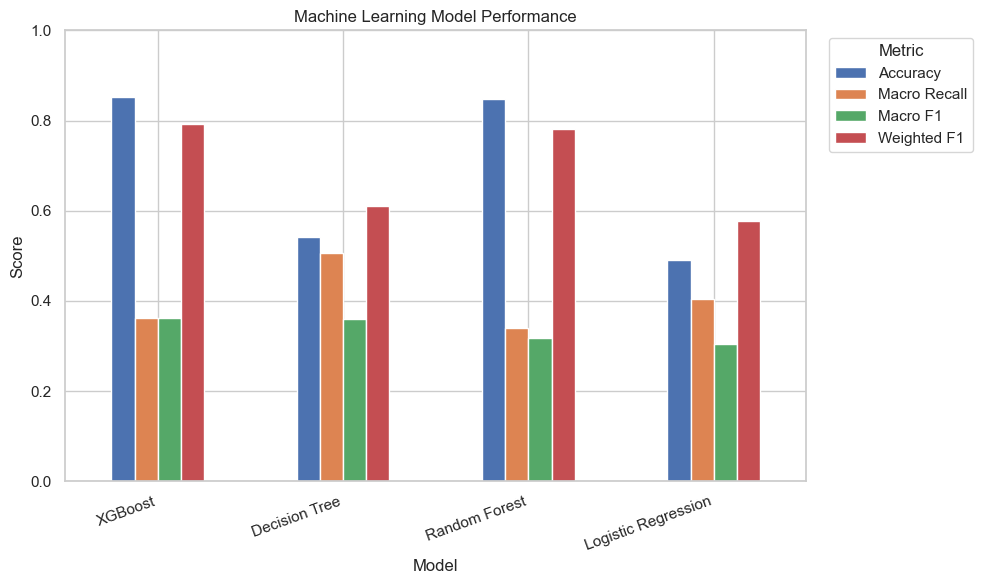

Saved: figures/model_comparison.png


In [20]:
results_df = (
    pd.DataFrame(results)
    .sort_values(
        by="Macro F1",
        ascending=False
    )
    .reset_index(drop=True)
)


display(
    results_df.round(4)
)


model_plot = (
    results_df
    .set_index("Model")
    [
        [
            "Accuracy",
            "Macro Recall",
            "Macro F1",
            "Weighted F1"
        ]
    ]
)


model_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Machine Learning Model Performance"
)

plt.xlabel("Model")
plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: figures/model_comparison.png")

## 21. Perform Cross-Validation

In [21]:
# Five-fold stratified validation helps determine
# whether performance is consistent across training subsets.

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)


cv_results = []


for model_name, model in models.items():

    fold_scores = []


    for train_index, validation_index in cv.split(
        X_train,
        y_train
    ):

        X_cv_train = X_train.iloc[
            train_index
        ]

        X_cv_validation = X_train.iloc[
            validation_index
        ]

        y_cv_train = y_train[
            train_index
        ]

        y_cv_validation = y_train[
            validation_index
        ]


        cv_pipeline = Pipeline(
            steps=[
                (
                    "preprocessor",
                    preprocessor
                ),
                (
                    "model",
                    model
                )
            ]
        )


        if model_name == "XGBoost":

            cv_weights = (
                compute_sample_weight(
                    class_weight="balanced",
                    y=y_cv_train
                )
            )

            cv_pipeline.fit(
                X_cv_train,
                y_cv_train,
                model__sample_weight=cv_weights
            )

        else:

            cv_pipeline.fit(
                X_cv_train,
                y_cv_train
            )


        cv_prediction = (
            cv_pipeline.predict(
                X_cv_validation
            )
        )


        fold_scores.append(
            f1_score(
                y_cv_validation,
                cv_prediction,
                average="macro",
                zero_division=0
            )
        )


    cv_results.append({

        "Model":
            model_name,

        "CV Macro F1":
            np.mean(
                fold_scores
            )
    })


cv_results_df = (
    pd.DataFrame(
        cv_results
    )
    .sort_values(
        by="CV Macro F1",
        ascending=False
    )
)


display(
    cv_results_df.round(4)
)

,Model,CV Macro F1
3,XGBoost,0.4925
1,Decision Tree,0.3921
2,Random Forest,0.3260
0,Logistic Regression,0.3121


## 22. Evaluate the Best Model

Best Model: XGBoost
                precision    recall  f1-score   support

  Fatal injury       1.00      0.03      0.06        31
Serious Injury       0.69      0.06      0.11       349
 Slight Injury       0.85      1.00      0.92      2084

      accuracy                           0.85      2464
     macro avg       0.85      0.36      0.36      2464
  weighted avg       0.83      0.85      0.79      2464



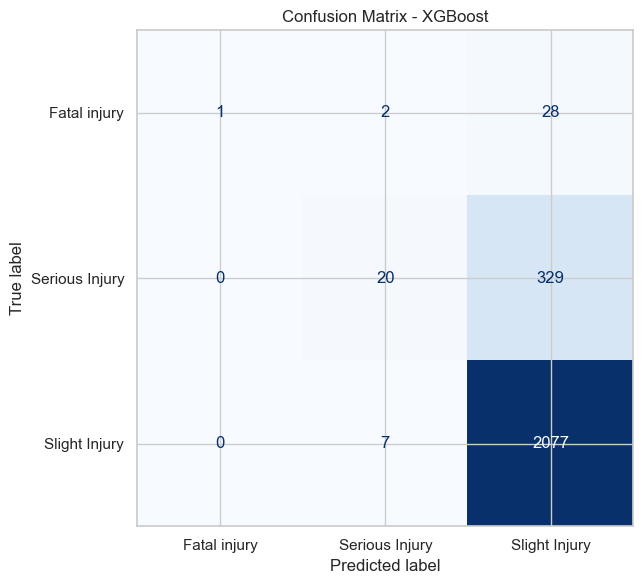

Saved: figures/best_model_confusion_matrix.png


In [22]:
# Select the model with the highest held-out Macro F1.
best_model_name = (
    results_df.iloc[0]["Model"]
)

best_prediction = predictions[
    best_model_name
]


print(
    "Best Model:",
    best_model_name
)


# Print detailed results only for the selected model.
print(
    classification_report(
        y_test,
        best_prediction,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)


cm = confusion_matrix(
    y_test,
    best_prediction
)


fig, ax = plt.subplots(
    figsize=(7, 6)
)


ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
).plot(
    ax=ax,
    cmap="Blues",
    colorbar=False
)


plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "best_model_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: figures/best_model_confusion_matrix.png")

## 23. Select a Tree-Based Model for Feature Importance

In [23]:
tree_model_names = [
    "Decision Tree",
    "Random Forest",
    "XGBoost"
]


tree_results = results_df[
    results_df["Model"].isin(
        tree_model_names
    )
]


best_tree_model_name = (
    tree_results.iloc[0]["Model"]
)


print(
    "Model Used for Feature Importance:",
    best_tree_model_name
)


best_tree_pipeline = fitted_models[
    best_tree_model_name
]


fitted_preprocessor = (
    best_tree_pipeline
    .named_steps[
        "preprocessor"
    ]
)


fitted_tree_model = (
    best_tree_pipeline
    .named_steps[
        "model"
    ]
)


feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)


importance_values = (
    fitted_tree_model
    .feature_importances_
)


encoded_importance = pd.DataFrame({

    "Encoded Feature":
        feature_names,

    "Importance":
        importance_values
})

Model Used for Feature Importance: XGBoost


## 24. Evaluate Multiclass ROC-AUC

In [24]:
from sklearn.metrics import roc_auc_score

roc_auc_results = []

for model_name, pipeline in fitted_models.items():

    # ROC-AUC requires predicted class probabilities.
    if hasattr(pipeline, "predict_proba"):

        # Generate predicted probabilities for each
        # accident-severity class.
        y_prob = pipeline.predict_proba(X_test)

        # Use One-vs-Rest multiclass ROC-AUC because the target
        # contains Fatal, Serious, and Slight Injury classes.
        # Macro ROC-AUC gives each severity class equal weight.
        macro_roc_auc = roc_auc_score(
            y_test,
            y_prob,
            multi_class="ovr",
            average="macro"
        )

        # Weighted ROC-AUC also considers the frequency
        # of each severity class.
        weighted_roc_auc = roc_auc_score(
            y_test,
            y_prob,
            multi_class="ovr",
            average="weighted"
        )

        roc_auc_results.append({
            "Model": model_name,
            "Macro ROC-AUC": macro_roc_auc,
            "Weighted ROC-AUC": weighted_roc_auc
        })


# Convert results to DataFrame.
roc_auc_df = pd.DataFrame(
    roc_auc_results
)

# Rank models by Macro ROC-AUC.
roc_auc_df = roc_auc_df.sort_values(
    by="Macro ROC-AUC",
    ascending=False
).reset_index(drop=True)


print("Multiclass ROC-AUC Comparison:\n")

display(
    roc_auc_df.round(4)
)

Multiclass ROC-AUC Comparison:



,Model,Macro ROC-AUC,Weighted ROC-AUC
0,XGBoost,0.7225,0.6725
1,Random Forest,0.7184,0.6792
2,Decision Tree,0.6189,0.6189
3,Logistic Regression,0.5913,0.5649


## 25. Test Class Weighting with XGBoost

Sample Weight Summary:
count    9852.0000
mean        1.0000
std         2.9218
min         0.3942
25%         0.3942
50%         0.3942
75%         0.3942
max        25.8583
dtype: float64

Weighted XGBoost Results:



,Metric,Weighted XGBoost
0,Accuracy,0.7492
1,Balanced Accuracy,0.4572
2,Macro Precision,0.4807
3,Macro Recall,0.4572
4,Macro F1,0.4581
5,Weighted F1,0.7651
6,Macro ROC-AUC,0.7462



Weighted XGBoost Classification Report:

                precision    recall  f1-score   support

  Fatal injury       0.29      0.16      0.21        31
Serious Injury       0.27      0.39      0.32       349
 Slight Injury       0.88      0.82      0.85      2084

      accuracy                           0.75      2464
     macro avg       0.48      0.46      0.46      2464
  weighted avg       0.79      0.75      0.77      2464



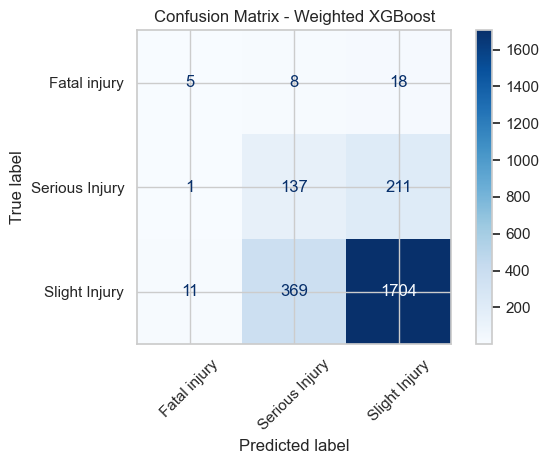

Saved: figures/weighted_xgboost_confusion_matrix.png


In [25]:
from sklearn.utils.class_weight import compute_sample_weight


# ------------------------------------------------------------
# 25.1. Calculate Balanced Sample Weights
# ------------------------------------------------------------

# The severity classes are highly imbalanced. Balanced sample
# weights give underrepresented classes greater influence
# during XGBoost training.

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

print("Sample Weight Summary:")

print(
    pd.Series(
        sample_weights
    ).describe().round(4)
)


# ------------------------------------------------------------
# 25.2. Create Weighted XGBoost Pipeline
# ------------------------------------------------------------

# Use the same preprocessing steps as the baseline models
# so the comparison remains consistent.

weighted_xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            XGBClassifier(
                random_state=42,
                eval_metric="mlogloss"
            )
        )
    ]
)


# ------------------------------------------------------------
# 25.3. Train Weighted XGBoost
# ------------------------------------------------------------

# Apply the balanced sample weights only during model training.

weighted_xgb_pipeline.fit(
    X_train,
    y_train,
    model__sample_weight=sample_weights
)


# ------------------------------------------------------------
# 25.4. Make Predictions
# ------------------------------------------------------------

weighted_xgb_pred = (
    weighted_xgb_pipeline.predict(
        X_test
    )
)

weighted_xgb_prob = (
    weighted_xgb_pipeline.predict_proba(
        X_test
    )
)


# ------------------------------------------------------------
# 25.5. Calculate Evaluation Metrics
# ------------------------------------------------------------

# Evaluate the weighted model using the same metrics used
# for the baseline models.

weighted_accuracy = accuracy_score(
    y_test,
    weighted_xgb_pred
)

weighted_balanced_accuracy = (
    balanced_accuracy_score(
        y_test,
        weighted_xgb_pred
    )
)

weighted_macro_precision = (
    precision_score(
        y_test,
        weighted_xgb_pred,
        average="macro",
        zero_division=0
    )
)

weighted_macro_recall = (
    recall_score(
        y_test,
        weighted_xgb_pred,
        average="macro",
        zero_division=0
    )
)

weighted_macro_f1 = (
    f1_score(
        y_test,
        weighted_xgb_pred,
        average="macro",
        zero_division=0
    )
)

weighted_f1 = (
    f1_score(
        y_test,
        weighted_xgb_pred,
        average="weighted",
        zero_division=0
    )
)

weighted_macro_auc = (
    roc_auc_score(
        y_test,
        weighted_xgb_prob,
        multi_class="ovr",
        average="macro"
    )
)


# ------------------------------------------------------------
# 25.6. Display Results
# ------------------------------------------------------------

weighted_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1",
        "Macro ROC-AUC"
    ],

    "Weighted XGBoost": [
        weighted_accuracy,
        weighted_balanced_accuracy,
        weighted_macro_precision,
        weighted_macro_recall,
        weighted_macro_f1,
        weighted_f1,
        weighted_macro_auc
    ]
})


print(
    "\nWeighted XGBoost Results:\n"
)

display(
    weighted_results.round(4)
)


# ------------------------------------------------------------
# 25.7. Classification Report
# ------------------------------------------------------------

# Examine class-level results to determine whether weighting
# improves detection of Fatal and Serious Injury cases.

print(
    "\nWeighted XGBoost Classification Report:\n"
)

print(
    classification_report(
        y_test,
        weighted_xgb_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)


# ------------------------------------------------------------
# 25.8. Confusion Matrix
# ------------------------------------------------------------

ConfusionMatrixDisplay.from_predictions(
    y_test,
    weighted_xgb_pred,
    display_labels=label_encoder.classes_,
    cmap="Blues",
    xticks_rotation=45
)

plt.title(
    "Confusion Matrix - Weighted XGBoost"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "weighted_xgboost_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: figures/weighted_xgboost_confusion_matrix.png")

## 26. Compare Baseline and Weighted XGBoost

In [26]:
# ------------------------------------------------------------
# 26.1. Get Baseline XGBoost Results
# ------------------------------------------------------------

baseline_xgb_row = results_df[
    results_df["Model"] == "XGBoost"
].iloc[0]


# Get the already calculated baseline Macro ROC-AUC
baseline_macro_auc = roc_auc_df.loc[
    roc_auc_df["Model"] == "XGBoost",
    "Macro ROC-AUC"
].iloc[0]


# ------------------------------------------------------------
# 26.2. Create Overall Comparison Table
# ------------------------------------------------------------

comparison_df = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1",
        "Macro ROC-AUC"
    ],

    "Baseline XGBoost": [
        baseline_xgb_row["Accuracy"],
        baseline_xgb_row["Balanced Accuracy"],
        baseline_xgb_row["Macro Precision"],
        baseline_xgb_row["Macro Recall"],
        baseline_xgb_row["Macro F1"],
        baseline_xgb_row["Weighted F1"],
        baseline_macro_auc
    ],

    "Weighted XGBoost": [
        weighted_accuracy,
        weighted_balanced_accuracy,
        weighted_macro_precision,
        weighted_macro_recall,
        weighted_macro_f1,
        weighted_f1,
        weighted_macro_auc
    ]
})


# ------------------------------------------------------------
# 26.3. Calculate Difference
# ------------------------------------------------------------

comparison_df["Difference"] = (
    comparison_df["Weighted XGBoost"]
    - comparison_df["Baseline XGBoost"]
)


# ------------------------------------------------------------
# 26.4. Display Overall Comparison
# ------------------------------------------------------------

print(
    "\nBaseline vs. Weighted XGBoost Comparison:\n"
)

display(
    comparison_df.round(4)
)


# ------------------------------------------------------------
# 26.5. Compare Class-Level Recall
# ------------------------------------------------------------

baseline_xgb_pred = predictions[
    "XGBoost"
]

baseline_report = classification_report(
    y_test,
    baseline_xgb_pred,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

weighted_report = classification_report(
    y_test,
    weighted_xgb_pred,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)


recall_comparison = pd.DataFrame({

    "Severity Class":
        label_encoder.classes_,

    "Baseline Recall": [
        baseline_report[class_name]["recall"]
        for class_name in label_encoder.classes_
    ],

    "Weighted Recall": [
        weighted_report[class_name]["recall"]
        for class_name in label_encoder.classes_
    ]
})


# ------------------------------------------------------------
# 26.6. Calculate Recall Improvement
# ------------------------------------------------------------

recall_comparison["Difference"] = (
    recall_comparison["Weighted Recall"]
    - recall_comparison["Baseline Recall"]
)


# ------------------------------------------------------------
# 26.7. Display Class-Level Recall Comparison
# ------------------------------------------------------------

print(
    "\nClass-Level Recall Comparison:\n"
)

display(
    recall_comparison.round(4)
)


Baseline vs. Weighted XGBoost Comparison:



,Metric,Baseline XGBoost,Weighted XGBoost,Difference
0,Accuracy,0.8515,0.7492,-0.1023
1,Balanced Accuracy,0.3621,0.4572,0.0951
2,Macro Precision,0.8477,0.4807,-0.3669
3,Macro Recall,0.3621,0.4572,0.0951
4,Macro F1,0.3626,0.4581,0.0955
5,Weighted F1,0.7934,0.7651,-0.0283
6,Macro ROC-AUC,0.7225,0.7462,0.0237



Class-Level Recall Comparison:



,Severity Class,Baseline Recall,Weighted Recall,Difference
0,Fatal injury,0.0323,0.1613,0.1290
1,Serious Injury,0.0573,0.3926,0.3352
2,Slight Injury,0.9966,0.8177,-0.1790


## 27. Group Feature Importance

In [27]:
# One-hot encoding creates multiple columns from a single
# categorical predictor. Group those encoded columns back to
# their original variables so feature importance is easier
# to interpret and report in the white paper.

original_features = (
    numeric_features
    +
    categorical_features
)


def get_original_feature(
    encoded_feature
):

    if "__" in encoded_feature:

        encoded_feature = (
            encoded_feature
            .split("__", 1)[1]
        )


    if encoded_feature in original_features:

        return encoded_feature


    matches = [

        feature

        for feature
        in categorical_features

        if encoded_feature.startswith(
            feature + "_"
        )
    ]


    if matches:

        return max(
            matches,
            key=len
        )


    return encoded_feature


encoded_importance[
    "Original Feature"
] = encoded_importance[
    "Encoded Feature"
].apply(
    get_original_feature
)


feature_importance = (
    encoded_importance
    .groupby(
        "Original Feature",
        as_index=False
    )
    ["Importance"]
    .sum()
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)


# Display the ten most important original predictors.
display(
    feature_importance
    .head(10)
    .round(4)
)

,Original Feature,Importance
0,Cause_of_accident,0.1066
1,Vehicle_movement,0.0950
2,Type_of_vehicle,0.0758
3,Area_accident_occured,0.0642
4,Day_of_week,0.0505
5,Type_of_collision,0.0476
6,Road_allignment,0.0472
7,Driving_experience,0.0426
8,Service_year_of_vehicle,0.0406
9,Pedestrian_movement,0.0400


## 28. Visualize Feature Importance

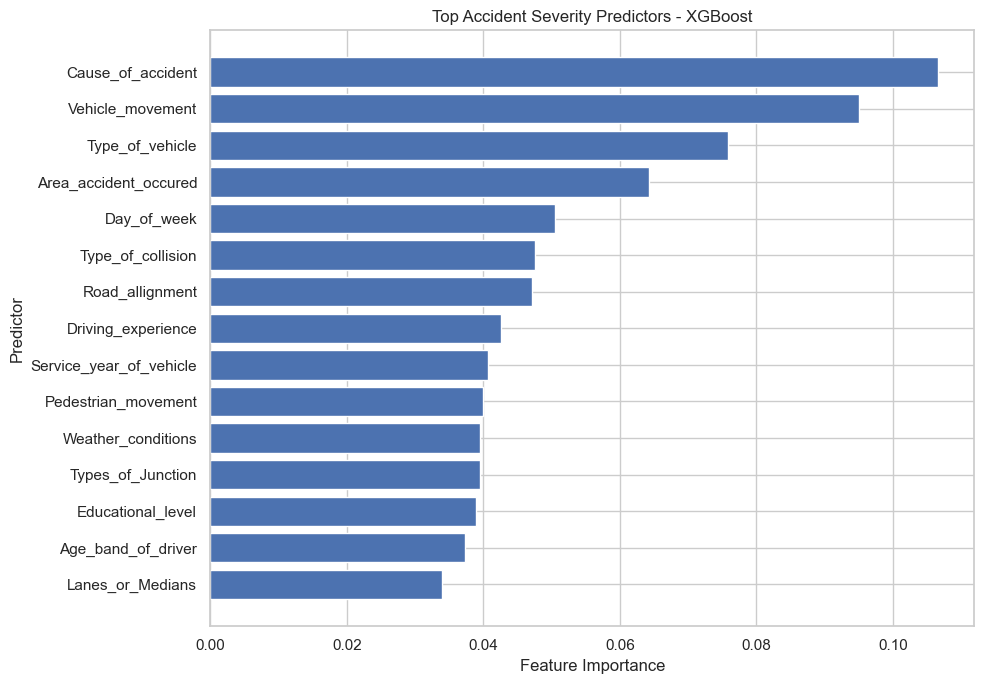

Saved: figures/feature_importance.png


In [28]:
top_features = (
    feature_importance
    .head(15)
    .sort_values(
        by="Importance",
        ascending=True
    )
)


plt.figure(
    figsize=(10, 7)
)


plt.barh(
    top_features[
        "Original Feature"
    ],
    top_features[
        "Importance"
    ]
)


plt.title(
    f"Top Accident Severity Predictors - {best_tree_model_name}"
)

plt.xlabel(
    "Feature Importance"
)

plt.ylabel(
    "Predictor"
)


plt.tight_layout()


plt.savefig(
    FIGURES_DIR / "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

print("Saved: figures/feature_importance.png")

## 29. Save Project Results

In [29]:
results_df.to_csv(
    RESULTS_DIR / "model_comparison.csv",
    index=False
)

cv_results_df.to_csv(
    RESULTS_DIR / "cross_validation_results.csv",
    index=False
)

association_df.to_csv(
    RESULTS_DIR / "association_results.csv",
    index=False
)

roc_auc_df.to_csv(
    RESULTS_DIR / "multiclass_roc_auc_results.csv",
    index=False
)

weighted_results.to_csv(
    RESULTS_DIR / "weighted_xgboost_results.csv",
    index=False
)

comparison_df.to_csv(
    RESULTS_DIR / "baseline_vs_weighted_xgboost.csv",
    index=False
)

recall_comparison.to_csv(
    RESULTS_DIR / "class_recall_comparison.csv",
    index=False
)

feature_importance.to_csv(
    RESULTS_DIR / "feature_importance.csv",
    index=False
)

missing_summary.to_csv(
    RESULTS_DIR / "missing_value_summary.csv"
)

print("Results saved:")
for file in sorted(RESULTS_DIR.glob("*.csv")):
    print(" -", f"results/{file.name}")

print("\nAnalysis completed successfully.")


Results saved:
 - results/association_results.csv
 - results/baseline_vs_weighted_xgboost.csv
 - results/class_recall_comparison.csv
 - results/cross_validation_results.csv
 - results/feature_importance.csv
 - results/missing_value_summary.csv
 - results/model_comparison.csv
 - results/multiclass_roc_auc_results.csv
 - results/weighted_xgboost_results.csv

Analysis completed successfully.


## 30. Saved Project Outputs

In [30]:
print("Figures:")
for file in sorted(FIGURES_DIR.glob("*.png")):
    print(" -", f"figures/{file.name}")

print("\nResults:")
for file in sorted(RESULTS_DIR.glob("*.csv")):
    print(" -", f"results/{file.name}")


Figures:
 - figures/accident_severity_distribution.png
 - figures/best_model_confusion_matrix.png
 - figures/feature_importance.png
 - figures/model_comparison.png
 - figures/severity_by_collision_type.png
 - figures/severity_by_day_of_week.png
 - figures/severity_by_light_conditions.png
 - figures/severity_by_road_surface.png
 - figures/severity_by_time_of_day.png
 - figures/severity_by_weather.png
 - figures/weighted_xgboost_confusion_matrix.png

Results:
 - results/association_results.csv
 - results/baseline_vs_weighted_xgboost.csv
 - results/class_recall_comparison.csv
 - results/cross_validation_results.csv
 - results/feature_importance.csv
 - results/missing_value_summary.csv
 - results/model_comparison.csv
 - results/multiclass_roc_auc_results.csv
 - results/weighted_xgboost_results.csv


## Conclusion

This project provides an end-to-end machine-learning workflow for road accident severity prediction. The analysis combines exploratory visualization, statistical association testing, preprocessing pipelines, multiple classification algorithms, cross-validation, ROC-AUC evaluation, class-imbalance handling, and feature-importance analysis.

The model comparison emphasizes macro-level metrics because the severity classes are imbalanced. The weighted XGBoost experiment provides an additional comparison of whether class weighting improves minority-class detection. Generated figures and evaluation tables are saved as separate portfolio outputs.
